In [303]:
print('wadodo')

wadodo


In [304]:
import pandas as pd

In [305]:
data = pd.read_csv(r'C:\mlops\End-to-End-Real-Time-Dynamic-Pricing-Engine\notebooks\data\raw\dynamic_pricing.csv')

In [306]:
data.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [307]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [1]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
cols_to_encode = data.select_dtypes(include=['object', 'category']).columns

print(f"Columns to encode: {list(cols_to_encode)}")


encoder = LabelEncoder()
for i in cols_to_encode:
    
    data[i] = encoder.fit_transform(data[i].astype(str))

NameError: name 'data' is not defined

In [309]:
data.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,2,2,13,4.47,3,1,90,284.257273
1,58,39,1,2,72,4.06,1,0,43,173.874753
2,42,31,0,2,0,3.99,0,1,76,329.795469
3,89,28,0,1,67,4.31,0,1,134,470.201232
4,78,22,0,1,74,3.77,0,0,149,579.681422


In [310]:
data.to_csv(r'C:\mlops\End-to-End-Real-Time-Dynamic-Pricing-Engine\notebooks\data\interim\interim0.csv')

In [311]:
df = pd.read_csv(r'C:\mlops\End-to-End-Real-Time-Dynamic-Pricing-Engine\notebooks\data\interim\interim0.csv')

In [312]:
df.head(2)

,Unnamed: 0,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,0,90,45,2,2,13,4.47,3,1,90,284.257273
1,1,58,39,1,2,72,4.06,1,0,43,173.874753


In [313]:
df = df.drop(columns=['Unnamed: 0'])

In [314]:
df.describe()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,1.0140,1.054000,50.031000,4.257220,1.551000,0.522000,99.58800,372.502623
std,23.701506,19.068346,0.8237,0.823263,29.313774,0.435781,1.137846,0.499766,49.16545,187.158756
min,20.000000,5.000000,0.0000,0.000000,0.000000,3.500000,0.000000,0.000000,10.00000,25.993449
25%,40.000000,11.000000,0.0000,0.000000,25.000000,3.870000,1.000000,0.000000,59.75000,221.365202
50%,60.000000,22.000000,1.0000,1.000000,51.000000,4.270000,2.000000,1.000000,102.00000,362.019426
75%,81.000000,38.000000,2.0000,2.000000,75.000000,4.632500,3.000000,1.000000,143.00000,510.497504
max,100.000000,89.000000,2.0000,2.000000,100.000000,5.000000,3.000000,1.000000,180.00000,836.116419


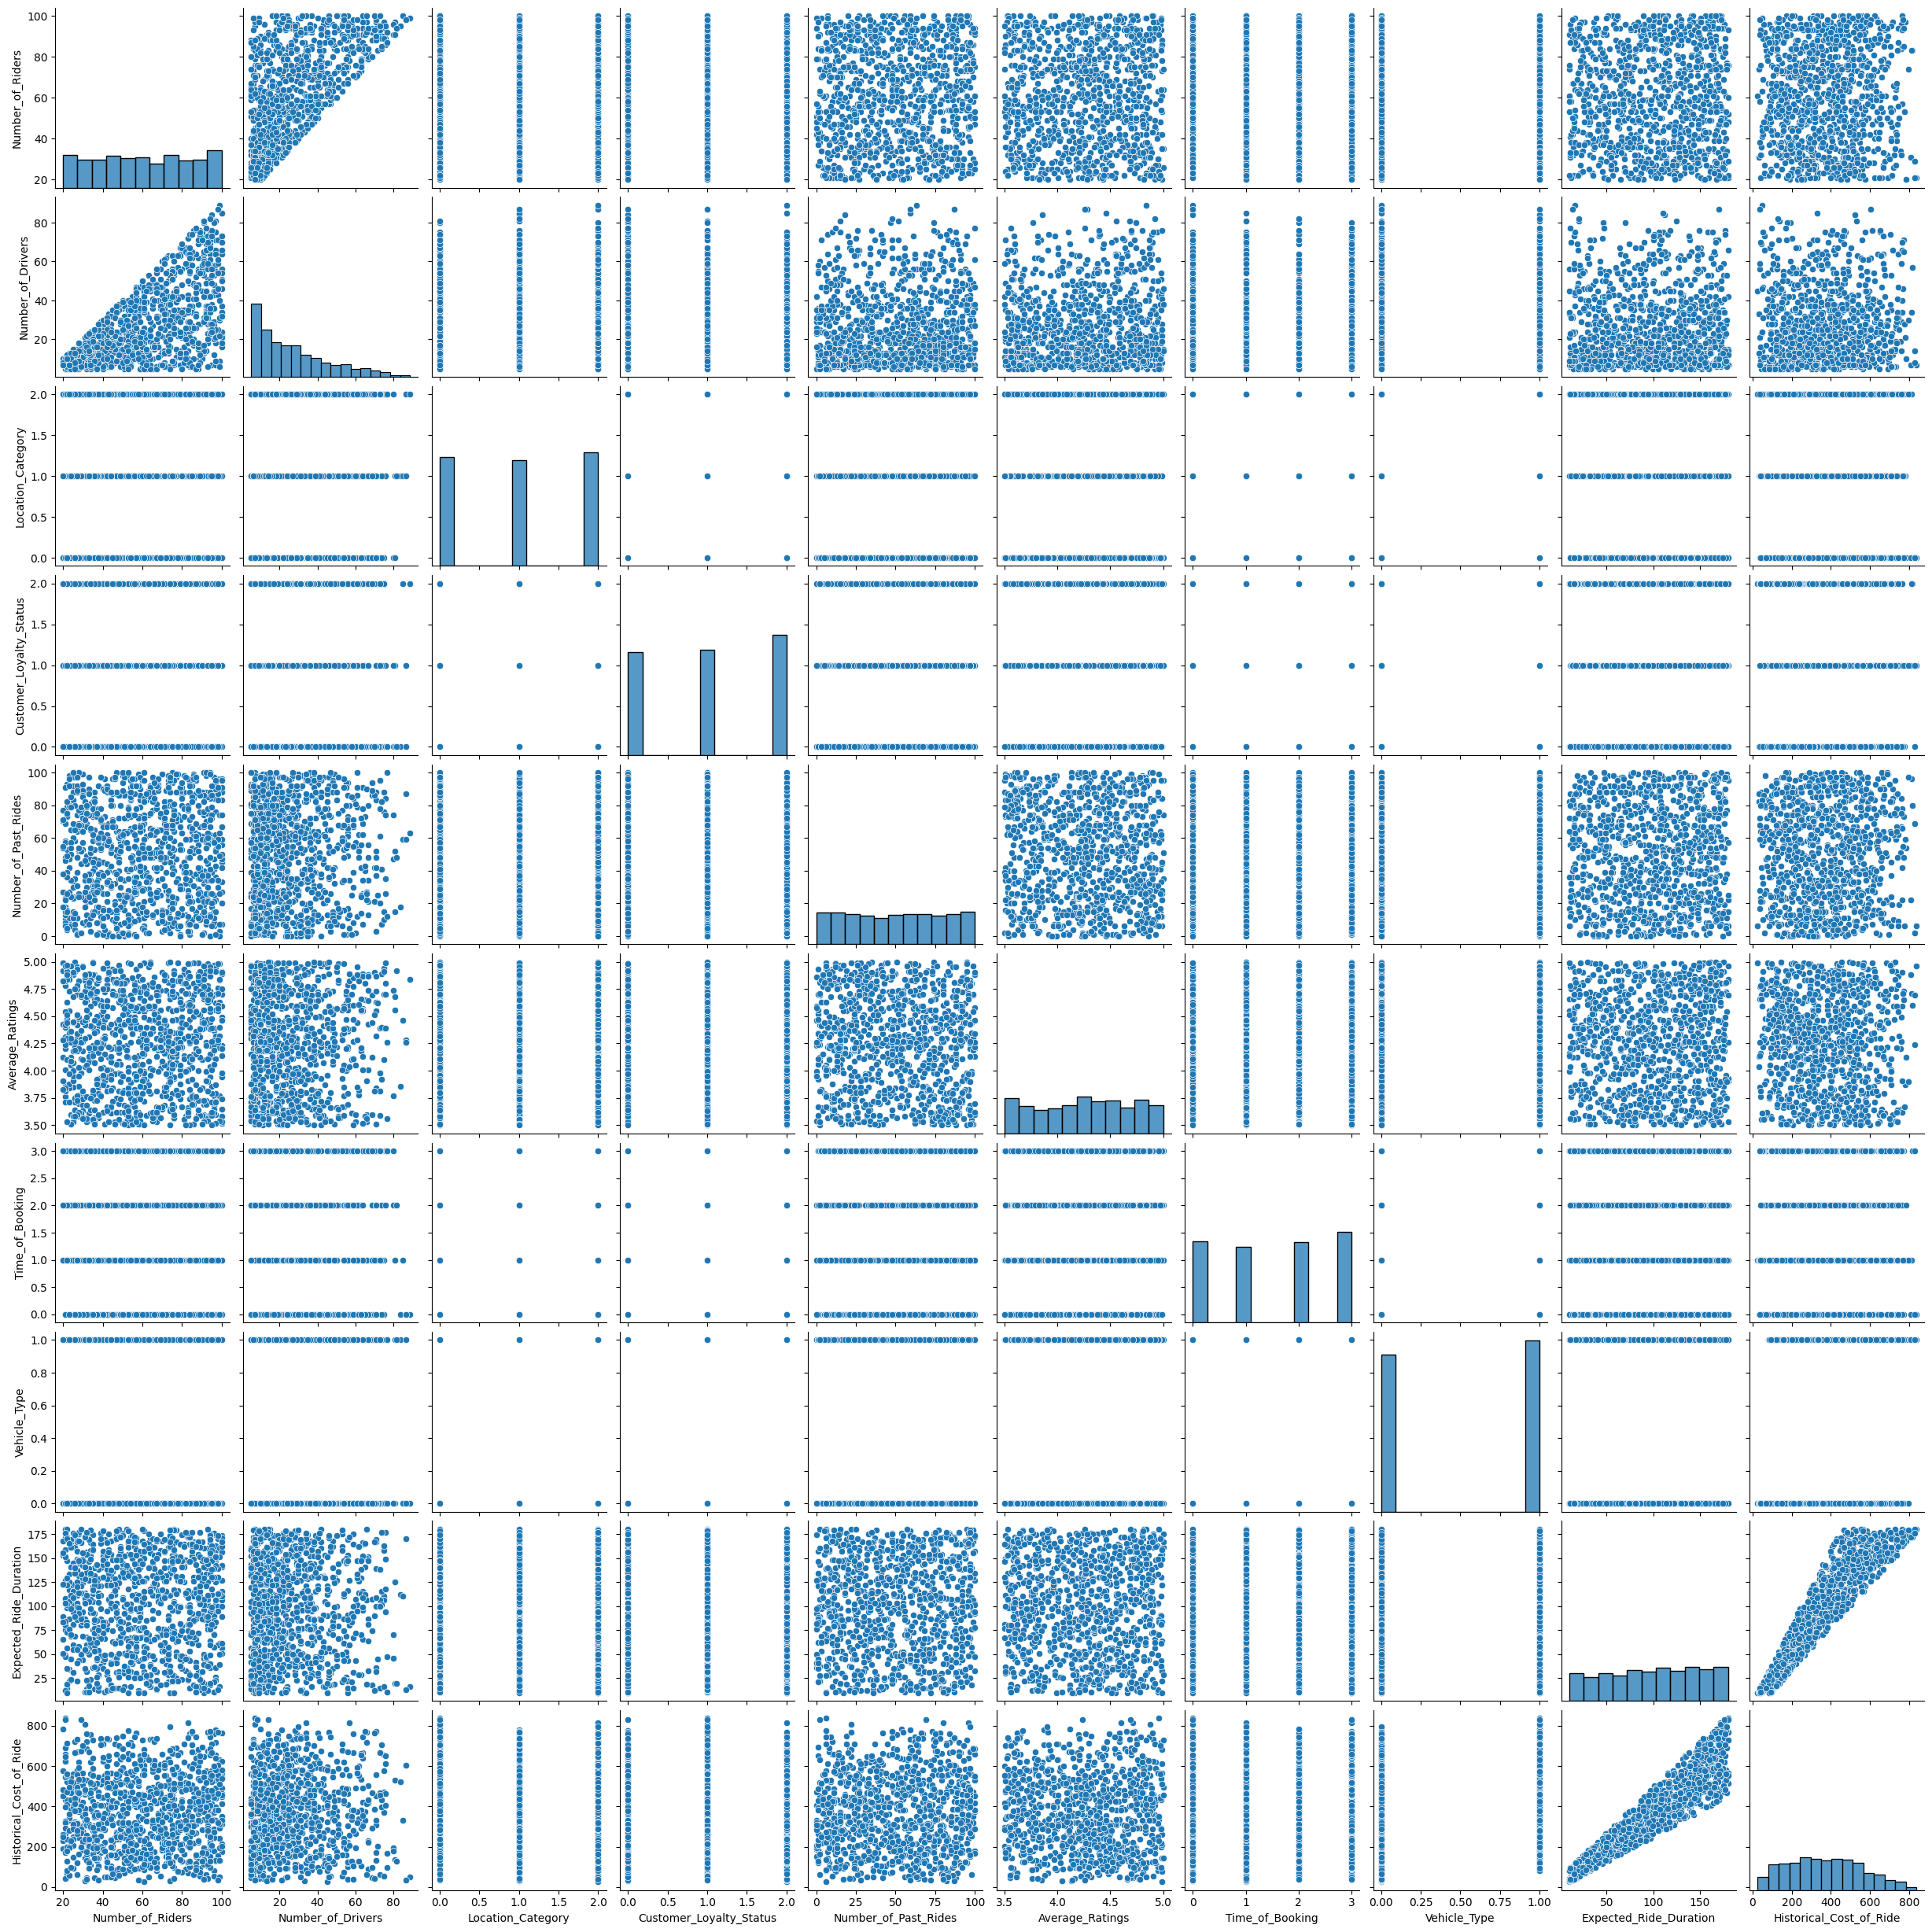

In [315]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df)

In [316]:
df['Supply-Demand Ratio'] = df['Number_of_Drivers']/df['Number_of_Riders']

In [317]:
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio
0,90,45,2,2,13,4.47,3,1,90,284.257273,0.500000
1,58,39,1,2,72,4.06,1,0,43,173.874753,0.672414
2,42,31,0,2,0,3.99,0,1,76,329.795469,0.738095
3,89,28,0,1,67,4.31,0,1,134,470.201232,0.314607
4,78,22,0,1,74,3.77,0,0,149,579.681422,0.282051


In [318]:
df.describe()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio
count,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,60.372000,27.076000,1.0140,1.054000,50.031000,4.257220,1.551000,0.522000,99.58800,372.502623,0.438162
std,23.701506,19.068346,0.8237,0.823263,29.313774,0.435781,1.137846,0.499766,49.16545,187.158756,0.211650
min,20.000000,5.000000,0.0000,0.000000,0.000000,3.500000,0.000000,0.000000,10.00000,25.993449,0.056818
25%,40.000000,11.000000,0.0000,0.000000,25.000000,3.870000,1.000000,0.000000,59.75000,221.365202,0.263158
50%,60.000000,22.000000,1.0000,1.000000,51.000000,4.270000,2.000000,1.000000,102.00000,362.019426,0.424242
75%,81.000000,38.000000,2.0000,2.000000,75.000000,4.632500,3.000000,1.000000,143.00000,510.497504,0.602849
max,100.000000,89.000000,2.0000,2.000000,100.000000,5.000000,3.000000,1.000000,180.00000,836.116419,0.898990


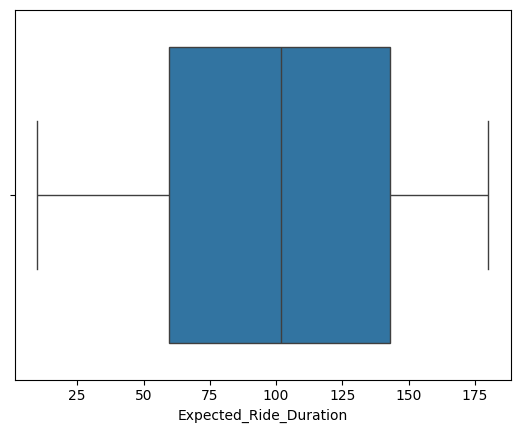

In [319]:
sns.boxplot(x=df['Expected_Ride_Duration'])
plt.show()

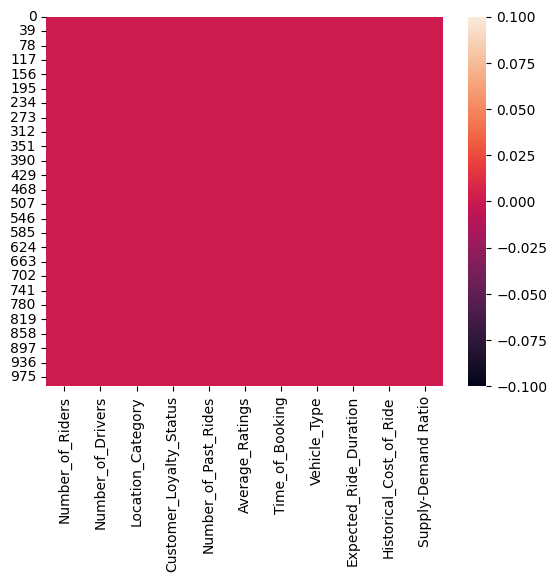

In [320]:
sns.heatmap(df.isnull())
plt.show()

In [321]:
df = df.drop(columns=['Number_of_Riders', 'Number_of_Drivers'])

In [322]:
df.head()

,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio
0,2,2,13,4.47,3,1,90,284.257273,0.500000
1,1,2,72,4.06,1,0,43,173.874753,0.672414
2,0,2,0,3.99,0,1,76,329.795469,0.738095
3,0,1,67,4.31,0,1,134,470.201232,0.314607
4,0,1,74,3.77,0,0,149,579.681422,0.282051


In [323]:
df.describe()

,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio
count,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,1.0140,1.054000,50.031000,4.257220,1.551000,0.522000,99.58800,372.502623,0.438162
std,0.8237,0.823263,29.313774,0.435781,1.137846,0.499766,49.16545,187.158756,0.211650
min,0.0000,0.000000,0.000000,3.500000,0.000000,0.000000,10.00000,25.993449,0.056818
25%,0.0000,0.000000,25.000000,3.870000,1.000000,0.000000,59.75000,221.365202,0.263158
50%,1.0000,1.000000,51.000000,4.270000,2.000000,1.000000,102.00000,362.019426,0.424242
75%,2.0000,2.000000,75.000000,4.632500,3.000000,1.000000,143.00000,510.497504,0.602849
max,2.0000,2.000000,100.000000,5.000000,3.000000,1.000000,180.00000,836.116419,0.898990


In [324]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
ss = StandardScaler()
mm = MinMaxScaler()

from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)


df['Number_of_Past_Rides'] = ss.fit_transform(df[['Number_of_Past_Rides']])
df['Expected_Ride_Duration'] = ss.fit_transform(df[['Expected_Ride_Duration']])
df['Average_Ratings'] = mm.fit_transform(df[['Average_Ratings']])
df['Historical_Cost_of_Ride'] = ss.fit_transform(df[['Historical_Cost_of_Ride']])

#df['Historical_Cost_of_Ride'] = qt.fit_transform(df[['Historical_Cost_of_Ride']])
df['Number_of_Past_Rides_Gaussian'] = qt.fit_transform(df[['Number_of_Past_Rides']])
df['Expected_Ride_Duration_Gaussian'] = qt.fit_transform(df[['Expected_Ride_Duration']])
df['Average_Ratings_Gaussian'] = qt.fit_transform(df[['Average_Ratings']])

In [325]:
df.head()

,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio,Number_of_Past_Rides_Gaussian,Expected_Ride_Duration_Gaussian,Average_Ratings_Gaussian
0,2,2,-1.263895,0.646667,3,1,-0.195113,-0.471736,0.500000,-1.096804,-0.191052,0.375793
1,1,2,0.749818,0.373333,1,0,-1.151547,-1.061811,0.672414,0.574460,-0.967422,-0.390065
2,0,2,-1.707594,0.326667,0,1,-0.480008,-0.228301,0.738095,-5.199338,-0.403108,-0.486994
3,0,1,0.579164,0.540000,0,1,0.700273,0.522270,0.314607,0.430727,0.515705,0.077301
4,0,1,0.818079,0.180000,0,0,1.005518,1.107522,0.282051,0.635270,0.834427,-0.898304


In [326]:
df.describe()

,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio,Number_of_Past_Rides_Gaussian,Expected_Ride_Duration_Gaussian,Average_Ratings_Gaussian
count,1000.0000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,1.0140,1.054000,3.552714e-17,0.504813,1.551000,0.522000,1.136868e-16,-7.993606e-17,0.438162,0.005600,-0.001109,-6.052511e-03
std,0.8237,0.823263,1.000500e+00,0.290521,1.137846,0.499766,1.000500e+00,1.000500e+00,0.211650,1.204476,1.147803,1.090245e+00
min,0.0000,0.000000,-1.707594e+00,0.000000,0.000000,0.000000,-1.823086e+00,-1.852345e+00,0.056818,-5.199338,-5.199338,-5.199338e+00
25%,0.0000,0.000000,-8.543262e-01,0.246667,1.000000,0.000000,-8.106899e-01,-8.079400e-01,0.263158,-0.666564,-0.669208,-6.703632e-01
50%,1.0000,1.000000,3.307267e-02,0.513333,2.000000,1.000000,4.908339e-02,-5.604035e-02,0.424242,0.000000,0.000000,-8.348749e-16
75%,2.0000,2.000000,8.522101e-01,0.755000,3.000000,1.000000,8.834196e-01,7.376835e-01,0.602849,0.666564,0.682458,6.709374e-01
max,2.0000,2.000000,1.705478e+00,1.000000,3.000000,1.000000,1.636357e+00,2.478355e+00,0.898990,5.199338,5.199338,5.199338e+00


In [327]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Historical_Cost_of_Ride', ylabel='Count'>

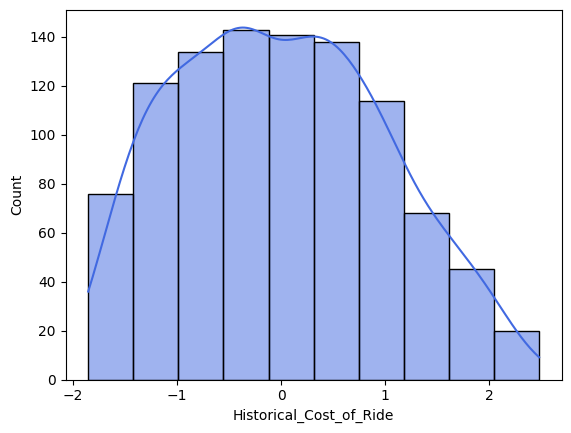

In [328]:
sns.histplot(df['Historical_Cost_of_Ride'], kde=True, bins=10, color='royalblue')

In [329]:
#from sklearn.preprocessing import PowerTransformer
#transformer = PowerTransformer(method='yeo-johnson')
#df['Historical_Cost_of_Ride'] = transformer.fit_transform(df[['Historical_Cost_of_Ride']])

<Axes: xlabel='Historical_Cost_of_Ride', ylabel='Count'>

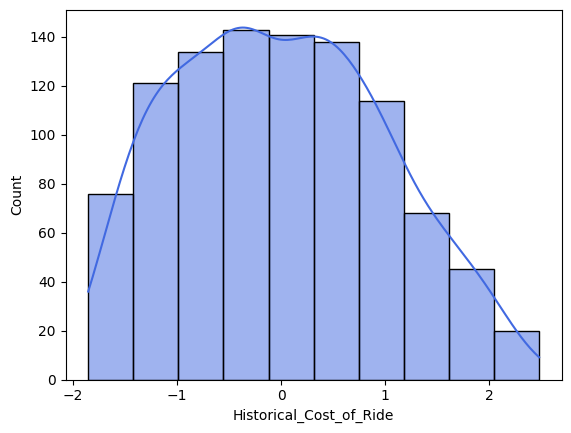

In [330]:
sns.histplot(df['Historical_Cost_of_Ride'], kde=True, bins=10, color='royalblue')

<Axes: xlabel='Supply-Demand Ratio', ylabel='Count'>

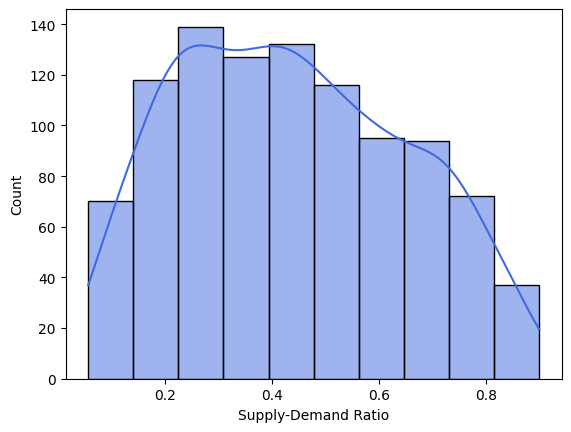

In [331]:
sns.histplot(df['Supply-Demand Ratio'], kde=True, bins=10, color='royalblue')

In [332]:
from sklearn.preprocessing import PowerTransformer
transformer = PowerTransformer(method='yeo-johnson')
df['Supply-Demand Ratio'] = transformer.fit_transform(df[['Supply-Demand Ratio']])

<Axes: xlabel='Supply-Demand Ratio', ylabel='Count'>

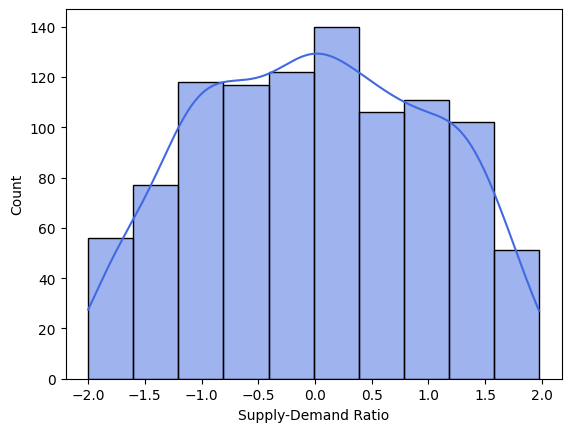

In [333]:
sns.histplot(df['Supply-Demand Ratio'], kde=True, bins=10, color='royalblue')

In [334]:
df.head(2)

,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio,Number_of_Past_Rides_Gaussian,Expected_Ride_Duration_Gaussian,Average_Ratings_Gaussian
0,2,2,-1.263895,0.646667,3,1,-0.195113,-0.471736,0.354130,-1.096804,-0.191052,0.375793
1,1,2,0.749818,0.373333,1,0,-1.151547,-1.061811,1.098251,0.574460,-0.967422,-0.390065


In [335]:
from sklearn.preprocessing import PowerTransformer
transformer = PowerTransformer(method='yeo-johnson')
df['Expected_Ride_Duration'] = transformer.fit_transform(df[['Expected_Ride_Duration']])
df['Average_Ratings'] = transformer.fit_transform(df[['Average_Ratings']])
df['Expected_Ride_Duration'] = transformer.fit_transform(df[['Expected_Ride_Duration']])

<Axes: xlabel='Number_of_Past_Rides', ylabel='Count'>

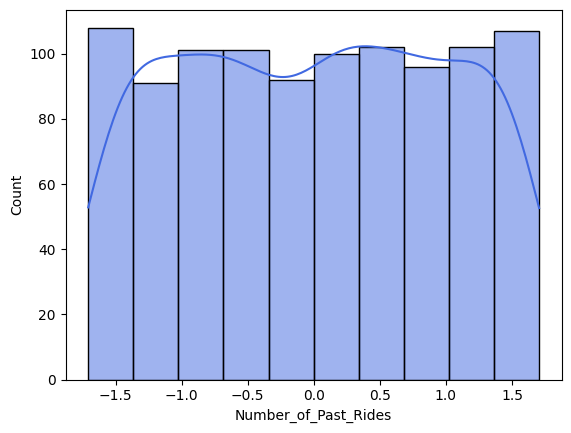

In [336]:
sns.histplot(df['Number_of_Past_Rides'], kde=True, bins=10, color='royalblue')

In [337]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)
df['Number_of_Past_Rides_Gaussian'] = qt.fit_transform(df[['Number_of_Past_Rides']])

<Axes: xlabel='Number_of_Past_Rides_Gaussian', ylabel='Count'>

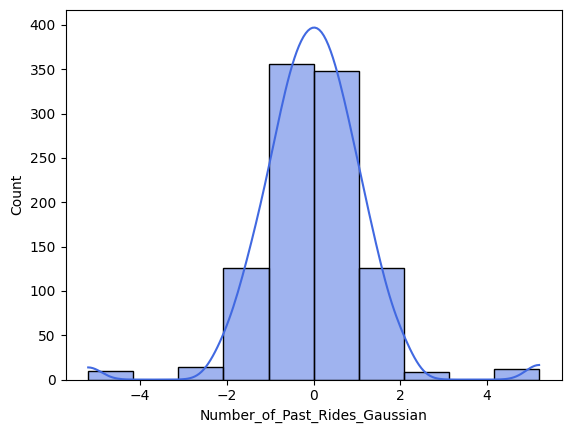

In [338]:
sns.histplot(df['Number_of_Past_Rides_Gaussian'], kde=True, bins=10, color='royalblue')

In [339]:
df.head()

,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply-Demand Ratio,Number_of_Past_Rides_Gaussian,Expected_Ride_Duration_Gaussian,Average_Ratings_Gaussian
0,2,2,-1.263895,0.488713,3,1,-0.250371,-0.471736,0.354130,-1.096804,-0.191052,0.375793
1,1,2,0.749818,-0.452538,1,0,-1.136168,-1.061811,1.098251,0.574460,-0.967422,-0.390065
2,0,2,-1.707594,-0.613292,0,1,-0.523020,-0.228301,1.363206,-5.199338,-0.403108,-0.486994
3,0,1,0.579164,0.121455,0,1,0.676629,0.522270,-0.539825,0.430727,0.515705,0.077301
4,0,1,0.818079,-1.118630,0,0,1.013862,1.107522,-0.708719,0.635270,0.834427,-0.898304


In [340]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
fs = SequentialFeatureSelector(model, k_features=9, forward=True)
x = df.drop(columns=['Historical_Cost_of_Ride'])
y = df['Historical_Cost_of_Ride']
fs.fit(x,y)
fs.k_score_

x_selected = df[list(fs.k_feature_names_)]
columns_to_drop = [col for col in df.columns if col not in fs.k_feature_names_ and col != 'Historical_Cost_of_Ride']
df.drop(columns=columns_to_drop, inplace=True)

In [342]:
fs.k_feature_names_
fs.k_score_


np.float64(0.8567483164638272)

In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Location_Category                1000 non-null   int64  
 1   Customer_Loyalty_Status          1000 non-null   int64  
 2   Average_Ratings                  1000 non-null   float64
 3   Time_of_Booking                  1000 non-null   int64  
 4   Vehicle_Type                     1000 non-null   int64  
 5   Historical_Cost_of_Ride          1000 non-null   float64
 6   Supply-Demand Ratio              1000 non-null   float64
 7   Number_of_Past_Rides_Gaussian    1000 non-null   float64
 8   Expected_Ride_Duration_Gaussian  1000 non-null   float64
 9   Average_Ratings_Gaussian         1000 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 78.3 KB


In [344]:
df.to_csv(r'C:\mlops\End-to-End-Real-Time-Dynamic-Pricing-Engine\notebooks\data\processed\processed.csv')

In [346]:
df.head()

,Location_Category,Customer_Loyalty_Status,Average_Ratings,Time_of_Booking,Vehicle_Type,Historical_Cost_of_Ride,Supply-Demand Ratio,Number_of_Past_Rides_Gaussian,Expected_Ride_Duration_Gaussian,Average_Ratings_Gaussian
0,2,2,0.488713,3,1,-0.471736,0.354130,-1.096804,-0.191052,0.375793
1,1,2,-0.452538,1,0,-1.061811,1.098251,0.574460,-0.967422,-0.390065
2,0,2,-0.613292,0,1,-0.228301,1.363206,-5.199338,-0.403108,-0.486994
3,0,1,0.121455,0,1,0.522270,-0.539825,0.430727,0.515705,0.077301
4,0,1,-1.118630,0,0,1.107522,-0.708719,0.635270,0.834427,-0.898304


['fitted_qt.pkl']